In [35]:
using DifferentialEquations, LinearAlgebra, Plots
Threads.nthreads()

20

### Initialization

In [36]:
#Basis state
r = [0;1]
g = [1;0]

#initial state of the system
α = 1
β = sqrt(1-α^2)
ψ_a = α.*r + β.*g
ψ_1 = g

ψ_0 = [ψ_a,g,g]
ρ_0 = complex(reduce(kron,ψ_0) * reduce(kron,ψ_0)');

### Functions

In [37]:
struct parameters
    Ω1::Float64
    Ω2::Float64     
    γ_Decay::Float64     
    γ_dephase::Float64
    V1_nn::Float64 
    V2_nn::Float64
 end

In [38]:
nothing
function (p::parameters)(t)
    global Δ1_0 = Δ1_0
    global δ1 =  δ1
    global Δ2_0 = Δ2_0
    global δ2 =  δ2

    tf = 0
    if t<tf
        return (Δ1_0-δ1*t, Δ2_0, p.Ω1, p.Ω2, p.γ_Decay, p.γ_dephase, p.V1_nn, p.V2_nn)
    else
        return (Δ1_0-δ1*t, Δ2_0-δ2*(t-tf), p.Ω1, p.Ω2, p.γ_Decay, p.γ_dephase, p.V1_nn, p.V2_nn)
    end
end


#Master Equation
nothing
function master_eqn(dρ,ρ,p,t)

    n_atoms = 2
    #2x2 Matrices
    σ_x = [0 1; 1 0]
    n = [0 0; 0 1]
    Π_g = [1 0; 0 0]
    I = [1 0; 0 1]
    σ_minus = [0 1; 0 0]
    σ_plus = [0 0; 1 0]
    σ_z = [1 0; 0 -1]

    #parameters
    Δ1_t, Δ2_t, Ω1, Ω2, γ_Decay, γ_dephase, V1_nn, V2_nn = p(t)


    #Hamiltonian elements
    nn_sys = [kron(n,n,I), kron(I,n,n), kron(n,I,n)]
    σminus_sys = [reduce(kron,[I,σ_minus,I]),reduce(kron,[I,I,σ_minus])]
    σplus_sys = [reduce(kron,[I,σ_plus,I]), reduce(kron,[I,I,σ_plus])]
    σz_sys = [reduce(kron,[I,σ_z,I]), reduce(kron,[I,I,σ_z])]
    n_sys = [reduce(kron,[I,n,I]), reduce(kron,[I,I,n])]
    σx_sys = [reduce(kron,[I,σ_x,I]), reduce(kron,[I,I,σ_x])]

    #Hamiltonian
    H = Ω1/2 .* σx_sys[1] + Ω2/2 .* σx_sys[2] + V1_nn .* nn_sys[1] + V2_nn .* nn_sys[3] +
        Δ1_t .* n_sys[1] + Δ2_t .*n_sys[2]

    #lindbaldian terms
    l_decay = zeros(2^(n_atoms+1),2^(n_atoms+1))
    l_dephase = zeros(2^(n_atoms+1),2^(n_atoms+1))

    for i in 1:2
        l_decay += γ_Decay.*(σminus_sys[i] * ρ * σplus_sys[i] - 0.5.*((σplus_sys[i]*σminus_sys[i]*ρ)
                         + (ρ*σplus_sys[i]*σminus_sys[i])))
        l_dephase += γ_dephase.*(σz_sys[i]* ρ *σz_sys[i] - ρ)
    end

    dρ .= -1im .* (H*ρ - ρ*H) + l_decay + l_dephase
end


#Solving the master equation
nothing
function solve_master_eqn(p)
    global δ1 = δ1
    tspan = (0.0,2*(Δ1_0+p(0)[end-1])/δ1)
    eqn = ODEProblem(master_eqn, ρ_0, tspan, p)
    sol = solve(eqn, Rodas3(autodiff=false),saveat=1)
    return sol
end


# Extracting populations from the solution
nothing
function rydberg_populations(sol)
    n = [0 0; 0 1]
    I = [1 0; 0 1]

    a = reduce(kron,[I,n,I])
    rydberg1 = [real(tr(a*ρ)) for ρ in sol.u]

    b = reduce(kron,[I,I,n])
    rydberg2 = [real(tr(b*ρ)) for ρ in sol.u]

    c = reduce(kron,[I,n,n])
    rydberg12 = [real(tr(c*ρ)) for ρ in sol.u]

    return rydberg1, rydberg2, rydberg12
end

rydberg_populations (generic function with 1 method)

### System Dynamics

In [39]:
Δ1_0 = 1031.60696125856
δ1 = 0.108573620475813
Δ2_0 = 1031.60696125856
δ2 = 0.108573620475813
p = parameters(1,1,0,0,-1000,-1000)

tspan = (0.0,582)
eqn = ODEProblem(master_eqn, ρ_0, tspan, p)
solution = solve(eqn, Rodas3(autodiff=false),saveat=1);

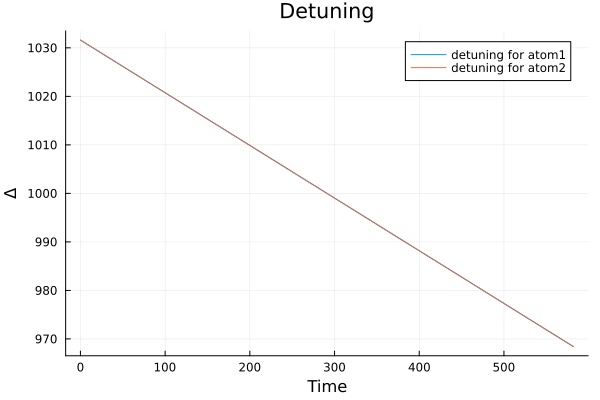

In [40]:
T = solution.t
Δ1_T = Array{Float64}(undef,length(T))
Δ2_T = Array{Float64}(undef,length(T))

for i in 1:length(T)
    t = T[i]
    Δ1_T[i] = p(t)[1]
    Δ2_T[i] = p(t)[2]
end
plot(T,Δ1_T,label="detuning for atom1",xaxis="Time",yaxis="Δ",title="Detuning")
plot!(T,Δ2_T,label="detuning for atom2",xaxis="Time",yaxis="Δ",title="Detuning")

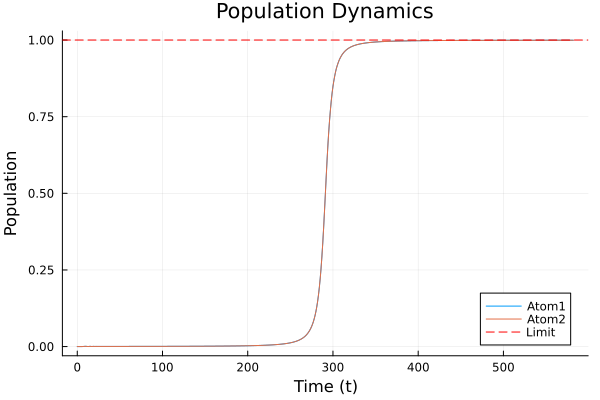

In [41]:
r1,r2,r12 = rydberg_populations(solution)

# Plotting the Rydberg state population over time
plot(solution.t, r1, label="Atom1", xlabel="Time (t)", ylabel="Population", title="Population Dynamics")#,xlim=(800,1200))
plot!(solution.t, r2, label="Atom2", xlabel="Time (t)", ylabel="Population", title="Population Dynamics")#,xlim=(800,1200))
hline!([1],color=:red,linestyle=:dash,label="Limit")

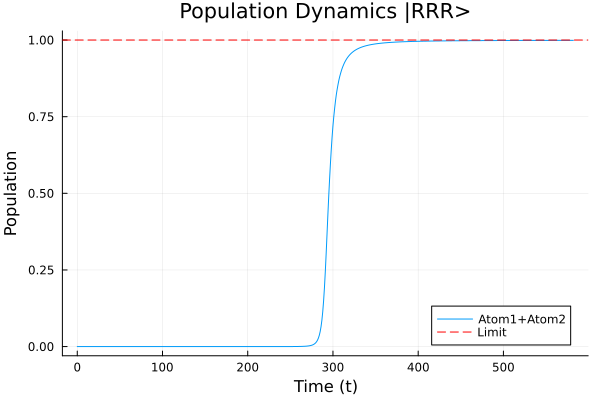

In [42]:
plot(solution.t, r12, label="Atom1+Atom2", xlabel="Time (t)", ylabel="Population", title="Population Dynamics |RRR>")
hline!([1],color=:red,linestyle=:dash,label="Limit")

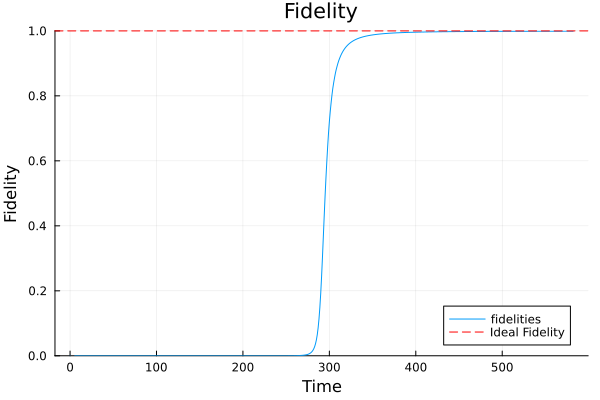

In [43]:
a = [r,r,r]
b = [g,g,g]
ψ_ideal = α*reduce(kron,a)+ β*reduce(kron,b)

fidelities = []
time = []
for (t,ρ) in zip(solution.t,solution.u)
    fidelity = ψ_ideal' * ρ * ψ_ideal
    push!(fidelities,fidelity)
    push!(time,t)
end

plot(time,real(fidelities),label="fidelities",xaxis="Time",yaxis="Fidelity",ylim=(0,1),title="Fidelity")
hline!([1], color=:red, linestyle=:dash, label="Ideal Fidelity")

### Observations

In [44]:
r1_end = r1[end]
r2_end = r2[end]
println("The population of the Rydberg state for atom1 is $r1_end which is equivalent to P_LZ = 1e-4 + some numerical inconsistencies
The population of Rydberg state for atom2 is $r2_end which is equivalent to P_LZ = 1e-4 but also depends on previous atom population")

The population of the Rydberg state for atom1 is 0.9994364902257741 which is equivalent to P_LZ = 1e-4 + some numerical inconsistencies
The population of Rydberg state for atom2 is 0.9994364902248722 which is equivalent to P_LZ = 1e-4 but also depends on previous atom population


### Fidelity as a function of detuning

In [45]:
struct Parameters
    Ω1::Float64
    Ω2::Float64     
    γ_Decay::Float64     
    γ_dephase::Float64
    V1_nn::Float64 
    V2_nn::Float64
    δ::Float64
 end

nothing
function (p::Parameters)(t)
    global Δ1_0 = Δ1_0
    # global δ1 =  δ1
    global Δ2_0 = Δ2_0
    # global δ2 =  δ2

    tf = 0
    if t<tf
        return (Δ1_0-p.δ *t, Δ2_0, p.Ω1, p.Ω2, p.γ_Decay, p.γ_dephase, p.V1_nn, p.V2_nn)
    else
        return (Δ1_0-p.δ *t, Δ2_0-p.δ *(t-tf), p.Ω1, p.Ω2, p.γ_Decay, p.γ_dephase, p.V1_nn, p.V2_nn)
    end
end

In [46]:
decay = 10 .^ range(log10(10^-5),log10(10^0),length=6);
sweep_rate = collect(range(0.01,1,length=10));

In [16]:
decay = 10 .^ range(log10(10^-5),log10(10^0),length=6);

sweep_rate = collect(range(0.01,1,length=10));

# Assume dephase and δ are already defined arrays
n = length(decay)
m = length(sweep_rate)

ψ_ideal = α*kron(r,r,r) + β*kron(g,g,g)
fidelity = Array{Float64}(undef,n,m)  # Ensure fidelity is pre-allocated

# Flatten the nested loops into a single loop that can be parallelized
Threads.@threads for idx in 1:n*m
    i = (idx-1) ÷ m + 1  # Calculate the row index
    j = (idx-1) % m + 1  # Calculate the column index

    a = decay[i]
    b = sweep_rate[j]

    Δ1_0 = 1031.60696125856
    Δ2_0 = 1031.60696125856
    T_optimal = 582.0
    p = Parameters(1,1,a,0,-1000,-1000,b)

    tspan = (0.0,T_optimal)
    eqn = ODEProblem(master_eqn, ρ_0, tspan, p)
    solution = solve(eqn, Rodas3(autodiff=false),saveat=1);

    f = tr(ψ_ideal' * solution[end] * ψ_ideal)
    fidelity[i, j] = real(f)
end


In [ ]:
plot(sweep_rate,real(fidelity[1,:]),label="fidelity for gamma=1e-5",xaxis="Sweep Rate",yaxis="Fidelity",ylim=(0,1),title="Fidelity")
plot!(sweep_rate,real(fidelity[2,:]),label="fidelity for gamma=1e-4",xaxis="Sweep Rate",yaxis="Fidelity",ylim=(0,1),title="Fidelity")
plot!(sweep_rate,real(fidelity[3,:]),label="fidelity for gamma=1e-3",xaxis="Sweep Rate",yaxis="Fidelity",ylim=(0,1),title="Fidelity")
plot!(sweep_rate,real(fidelity[4,:]),label="fidelity for gamma=1e-2",xaxis="Sweep Rate",yaxis="Fidelity",ylim=(0,1),title="Fidelity")
plot!(sweep_rate,real(fidelity[5,:]),label="fidelity for gamma=1e-1",xaxis="Sweep Rate",yaxis="Fidelity",ylim=(0,1),title="Fidelity")
plot!(sweep_rate,real(fidelity[6,:]),label="fidelity for gamma=1e-0",xaxis="Sweep Rate",yaxis="Fidelity",ylim=(0,1),title="Fidelity")

In [18]:
best_fidelity = []
for i in 1:n
    push!(best_fidelity,maximum(fidelity[i,:]))
end

In [ ]:
plot(decay,best_fidelity,xscale=:log10,label="Best Fidelity",xaxis="Decay Rate",yaxis="Best Fidelity",ylim=(0,1),title="Fidelity")

## Results from trial.jld2

In [125]:
using Plots, JLD2, LaTeXStrings, FileIO

@load "/home/agfleischhauer/roq68sum/rydberg_qec/codework/results_data/2atoms/optimal_decay.jld2"

decay = decay
sweep_rate = sweep_rate
fidelity = fidelity;

In [126]:
length(decay), length(sweep_rate)

(5, 1000)

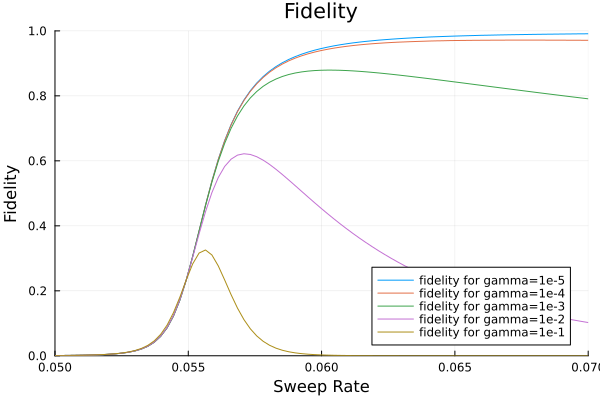

In [144]:
plot(sweep_rate,real(fidelity[1,:]),xlim=(0.05,0.07),label="fidelity for gamma=1e-5",xaxis="Sweep Rate",yaxis="Fidelity",ylim=(0,1),title="Fidelity",legend=:bottomright)
plot!(sweep_rate,real(fidelity[2,:]),label="fidelity for gamma=1e-4",xaxis="Sweep Rate",yaxis="Fidelity",ylim=(0,1),title="Fidelity")
plot!(sweep_rate,real(fidelity[3,:]),label="fidelity for gamma=1e-3",xaxis="Sweep Rate",yaxis="Fidelity",ylim=(0,1),title="Fidelity")
plot!(sweep_rate,real(fidelity[4,:]),label="fidelity for gamma=1e-2",xaxis="Sweep Rate",yaxis="Fidelity",ylim=(0,1),title="Fidelity")
plot!(sweep_rate,real(fidelity[5,:]),label="fidelity for gamma=1e-1",xaxis="Sweep Rate",yaxis="Fidelity",ylim=(0,1),title="Fidelity")

In [128]:
best_fidelity = []
best_sweep_rate = []
for i in 1:length(decay)
    push!(best_fidelity,maximum(fidelity[i,:]))
    push!(best_sweep_rate,sweep_rate[argmax(fidelity[i,:])])
end

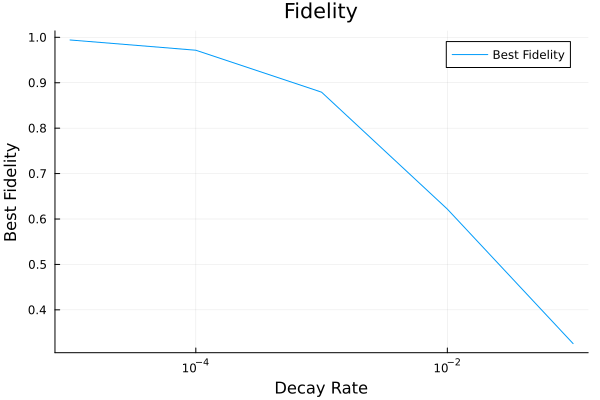

In [129]:
plot(decay,best_fidelity,xscale=:log10,label="Best Fidelity",xaxis="Decay Rate",yaxis="Best Fidelity",title="Fidelity")

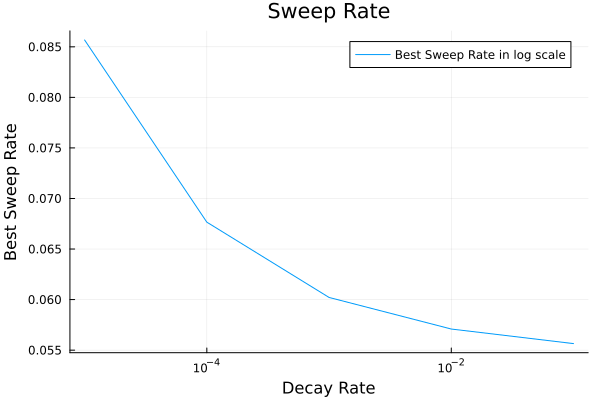

In [130]:
plot(decay,best_sweep_rate,xscale=:log10,label="Best Sweep Rate in log scale",xaxis="Decay Rate",yaxis="Best Sweep Rate",title="Sweep Rate")

In [131]:
# x1 = []
# x2 = []
# for i in 1:length(decay)
#     push!(x1,decay[i]^2/best_sweep_rate[i])
#     push!(x2,1/best_sweep_rate[i])
# end

In [132]:
# using SpecialFunctions

# I_lim_theory = []
# I_theory = []

# function I_analytic(α,γ,V=1.0)
#     # return (2 * pi * γ * V^2)/α * (1 - exp(-2* pi* V^2/α))/(γ^2 + 4* V^2)^0.5
#     return (1 - exp(-2*pi*V^2/α)) * exp(-γ/α)
# end


# for i in 1:length(sweep_rate)
#     # W = sqrt(pi*best_sweep_rate[i])/( gamma(-1im*1/best_sweep_rate[i]) * (1 + (2/decay[i])^2)^0.25 )
#     I = I_analytic(sweep_rate[i],decay[end])
    
#     #Limiting case
#     I_lim = 1 - exp(-2*pi/sweep_rate[i])

#     push!(I_theory,I)
#     push!(I_lim_theory,I_lim)
# end

In [133]:
# plot(sweep_rate,real(fidelity[end,:]),label="Numerical Fidelity",xaxis="Decay Rate",yaxis="Fidelity",title="Fidelity")
# plot!(sweep_rate,I_theory,label="Analytical Fidelity",xaxis="Sweep Rate",yaxis="Fidelity",title="Fidelity under limiting case")